# 05 · Modelling Price

**Goal:** estimate how much each listing characteristic adds to price *while holding the others constant*, and check how well listing attributes can predict price at all.

Two models predict `log_price`:
1. **Linear regression:** transparent. Each coefficient converts to a % price effect: `e^β − 1`.
2. **Random forest:** captures non-linearities and interactions; used to check how much accuracy the linear model leaves on the table.

**Honesty rules:** fixed 80/20 train/test split (random_state = 42); all metrics reported on the held-out test set; a naive baseline for comparison; 5-fold cross-validation to check the split was not lucky. Features are only things a host knows *before* setting a price (nothing derived from price).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.style import (BLUE, DATA_PROCESSED, NEUTRAL, ORANGE, SURFACE, TEXT_SECONDARY, euro, save_fig,
                       set_style)

set_style()
SEED = 42
df = pd.read_csv(DATA_PROCESSED / "listings_clean.csv")
print(f"{len(df):,} listings")

6,086 listings


## 1. Feature preparation

| Group | Features | Treatment |
|---|---|---|
| Room type | `room_type` | one-hot; baseline = *Entire home/apt*; hotel + shared rooms (26 listings) merged into *Hotel/shared room* |
| Location | `neighbourhood_cleansed`, `dist_centre_km` | one-hot; baseline = *De Baarsjes - Oud-West* (largest) |
| Size | `accommodates`, `bedrooms`, `bathrooms`, `bath_shared` | numeric / flag |
| Amenities | `amenity_count`, 12 `amen_*` flags | numeric / flags (wifi dropped: 98.7% have it) |
| Reputation | `host_is_superhost`, `has_reviews`, `review_scores_rating`, `log_reviews` | missing ratings (no reviews) filled with the median *and* flagged by `has_reviews` |
| Host / rules | `is_multi_host`, `host_tenure_years`, `log_min_nights`, `availability_365` | numeric / flag |

In [2]:
X = pd.DataFrame(index=df.index)
room = df["room_type"].replace({"Hotel room": "Hotel/shared room", "Shared room": "Hotel/shared room"})
X = X.join(pd.get_dummies(room, prefix="room").drop(columns="room_Entire home/apt"))
X = X.join(pd.get_dummies(df["neighbourhood_cleansed"], prefix="nbh").drop(columns="nbh_De Baarsjes - Oud-West"))

numeric = ["accommodates", "bedrooms", "bathrooms", "amenity_count", "dist_centre_km",
           "host_tenure_years", "availability_365"]
flags = ["bath_shared", "host_is_superhost", "is_multi_host", "has_reviews"] + \
        [c for c in df.columns if c.startswith("amen_") and c != "amen_wifi"]
X = X.join(df[numeric + flags])
X["review_scores_rating"] = df["review_scores_rating"].fillna(df["review_scores_rating"].median())
X["log_reviews"] = np.log1p(df["number_of_reviews"])
X["log_min_nights"] = np.log1p(df["minimum_nights"])
X = X.astype(float)
y = df["log_price"]
print(f"Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

Feature matrix: 6,086 rows × 48 features
Train: 4,868   Test: 1,218


## 2. Fit models

In [3]:
lin = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=3, max_features=0.4,
                           random_state=SEED, n_jobs=-1).fit(X_train, y_train)


def evaluate(name, pred_log):
    pred_eur, true_eur = np.expm1(pred_log), np.expm1(y_test)
    return {
        "model": name,
        "R² (log price)": r2_score(y_test, pred_log),
        "MAE (log price)": mean_absolute_error(y_test, pred_log),
        "MAE (€)": mean_absolute_error(true_eur, pred_eur),
        "Median abs % error": np.median(np.abs(pred_eur / true_eur - 1)) * 100,
    }

baseline = np.full(len(y_test), y_train.median())
results = pd.DataFrame([
    evaluate("Baseline (predict median)", baseline),
    evaluate("Linear regression", lin.predict(X_test)),
    evaluate("Random forest", rf.predict(X_test)),
]).set_index("model")
results.round(3)

,R² (log price),MAE (log price),MAE (€),Median abs % error
model,,,,
Baseline (predict median),-0.001,0.400,129.574,31.858
Linear regression,0.641,0.235,80.350,19.238
Random forest,0.674,0.221,76.563,18.050


In [4]:
cv = KFold(5, shuffle=True, random_state=SEED)
cv_lin = cross_val_score(LinearRegression(), X, y, cv=cv, scoring="r2")
cv_rf = cross_val_score(RandomForestRegressor(n_estimators=200, min_samples_leaf=3, max_features=0.4,
                                              random_state=SEED, n_jobs=-1), X, y, cv=cv, scoring="r2")
print(f"5-fold CV R²  linear: {cv_lin.mean():.3f} ± {cv_lin.std():.3f}")
print(f"5-fold CV R²  forest: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"Train R² forest: {r2_score(y_train, rf.predict(X_train)):.3f} (vs test {results.loc['Random forest', 'R² (log price)']:.3f})")

5-fold CV R²  linear: 0.640 ± 0.015
5-fold CV R²  forest: 0.674 ± 0.012


Train R² forest: 0.879 (vs test 0.674)


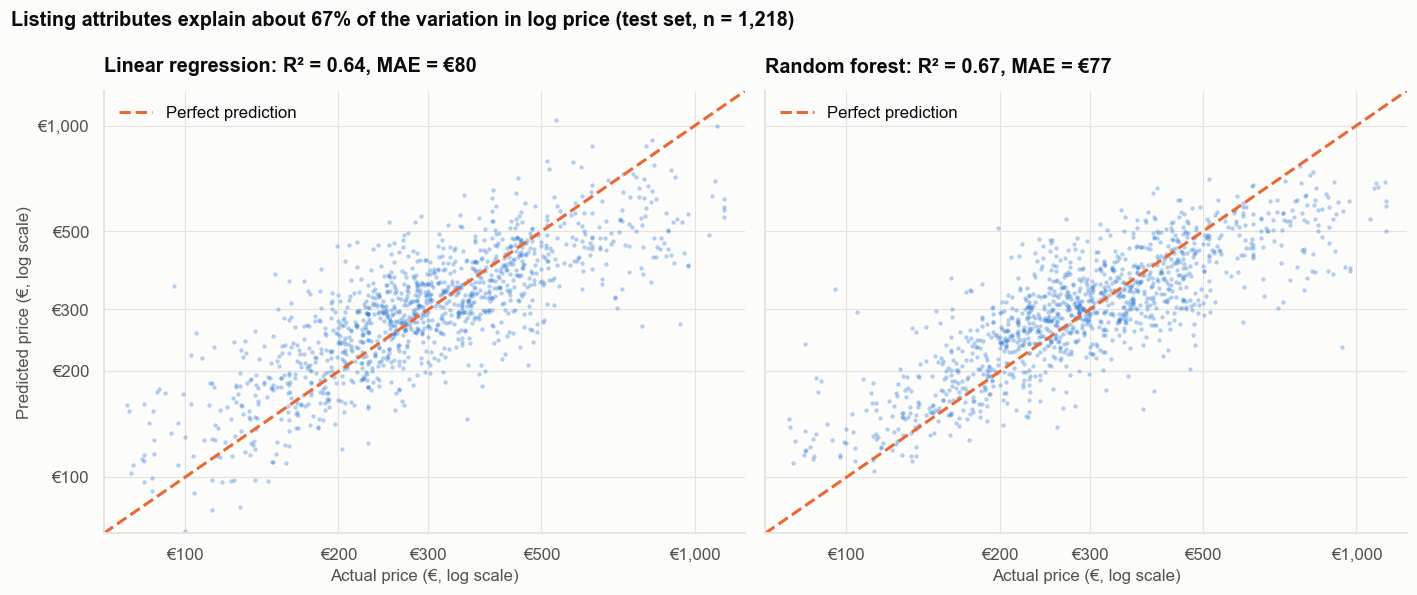

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
lims = [np.expm1(y_test).min() * 0.9, np.expm1(y_test).max() * 1.1]
for ax, (name, model) in zip(axes, [("Linear regression", lin), ("Random forest", rf)]):
    pred = np.expm1(model.predict(X_test))
    ax.scatter(np.expm1(y_test), pred, s=8, alpha=0.35, color=BLUE, linewidths=0)
    ax.plot(lims, lims, color=ORANGE, ls="--", lw=2, label="Perfect prediction")
    ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims, xlabel="Actual price (€, log scale)",
           title=f"{name}: R² = {results.loc[name, 'R² (log price)']:.2f}, MAE = €{results.loc[name, 'MAE (€)']:.0f}")
    ax.title.set_fontsize(11.5)
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_formatter(euro)
        axis.set_minor_formatter(plt.NullFormatter())
    ax.set_xticks([100, 200, 300, 500, 1000])
    ax.set_yticks([100, 200, 300, 500, 1000])
    ax.legend(loc="upper left")
axes[0].set_ylabel("Predicted price (€, log scale)")
best = results["R² (log price)"].idxmax()
fig.suptitle(f"Listing attributes explain about {results.loc[best, 'R² (log price)']:.0%} of the variation in log price (test set, n = {len(y_test):,})",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "05_actual_vs_predicted")
plt.show()

## 3. Interpreting the linear model
Coefficients are on log price, so `e^β − 1` is the % change in price for a one-unit change, **holding all other features constant**. 95% confidence intervals use the classical OLS standard errors.

In [6]:
Xd = np.column_stack([np.ones(len(X_train)), X_train.values])
resid = y_train.values - lin.predict(X_train)
sigma2 = resid @ resid / (Xd.shape[0] - Xd.shape[1])
se = np.sqrt(np.diag(sigma2 * np.linalg.pinv(Xd.T @ Xd)))[1:]
coef = pd.DataFrame({"beta": lin.coef_, "se": se}, index=X.columns)
coef["effect_%"] = (np.exp(coef["beta"]) - 1) * 100
coef["ci_low_%"] = (np.exp(coef["beta"] - 1.96 * coef["se"]) - 1) * 100
coef["ci_high_%"] = (np.exp(coef["beta"] + 1.96 * coef["se"]) - 1) * 100
coef["significant"] = (coef["ci_low_%"] > 0) | (coef["ci_high_%"] < 0)

LABELS = {
    "room_Private room": "Private room (vs entire home)",
    "room_Hotel/shared room": "Hotel/shared room (vs entire home)",
    "accommodates": "+1 guest capacity", "bedrooms": "+1 bedroom", "bathrooms": "+1 bathroom",
    "bath_shared": "Shared bathroom", "amenity_count": "+10 amenities", "dist_centre_km": "+1 km from Dam Square",
    "host_is_superhost": "Superhost", "is_multi_host": "Multi-listing host", "has_reviews": "Has any reviews",
    "review_scores_rating": "+0.1 review score", "log_reviews": "2× number of reviews",
    "host_tenure_years": "+1 year host tenure", "availability_365": "+30 days available/yr",
    "log_min_nights": "2× minimum nights",
    "amen_washer": "Washer", "amen_kitchen": "Kitchen", "amen_dishwasher": "Dishwasher",
    "amen_workspace": "Dedicated workspace", "amen_self_checkin": "Self check-in", "amen_balcony": "Patio/balcony",
    "amen_bathtub": "Bathtub", "amen_waterfront": "Waterfront", "amen_air_conditioning": "Air conditioning",
    "amen_elevator": "Elevator", "amen_free_parking": "Free parking",
}
# Rescale a few coefficients to more meaningful units
SCALE = {"amenity_count": 10, "review_scores_rating": 0.1, "availability_365": 30,
         "log_reviews": np.log(2), "log_min_nights": np.log(2)}
eff = coef.loc[list(LABELS)].copy()
for col, k in SCALE.items():
    for c in ["beta"]:
        eff.loc[col, c] = coef.loc[col, c] * k
    eff.loc[col, "effect_%"] = (np.exp(coef.loc[col, "beta"] * k) - 1) * 100
    lo, hi = coef.loc[col, "beta"] - 1.96 * coef.loc[col, "se"], coef.loc[col, "beta"] + 1.96 * coef.loc[col, "se"]
    eff.loc[col, "ci_low_%"], eff.loc[col, "ci_high_%"] = (np.exp(lo * k) - 1) * 100, (np.exp(hi * k) - 1) * 100
eff.index = [LABELS[i] for i in eff.index]
eff = eff.sort_values("effect_%")
eff[["effect_%", "ci_low_%", "ci_high_%", "significant"]].round(1).iloc[::-1]

,effect_%,ci_low_%,ci_high_%,significant
Air conditioning,12.5,9.9,15.2,True
+1 bedroom,12.2,10.4,14.1,True
+1 guest capacity,11.2,10.1,12.3,True
Has any reviews,10.4,6.5,14.5,True
Dishwasher,9.8,7.0,12.6,True
+1 bathroom,9.6,7.4,11.8,True
Free parking,7.9,3.8,12.2,True
Bathtub,7.5,5.2,9.9,True
Patio/balcony,4.9,2.9,7.0,True
Kitchen,3.7,0.3,7.2,True


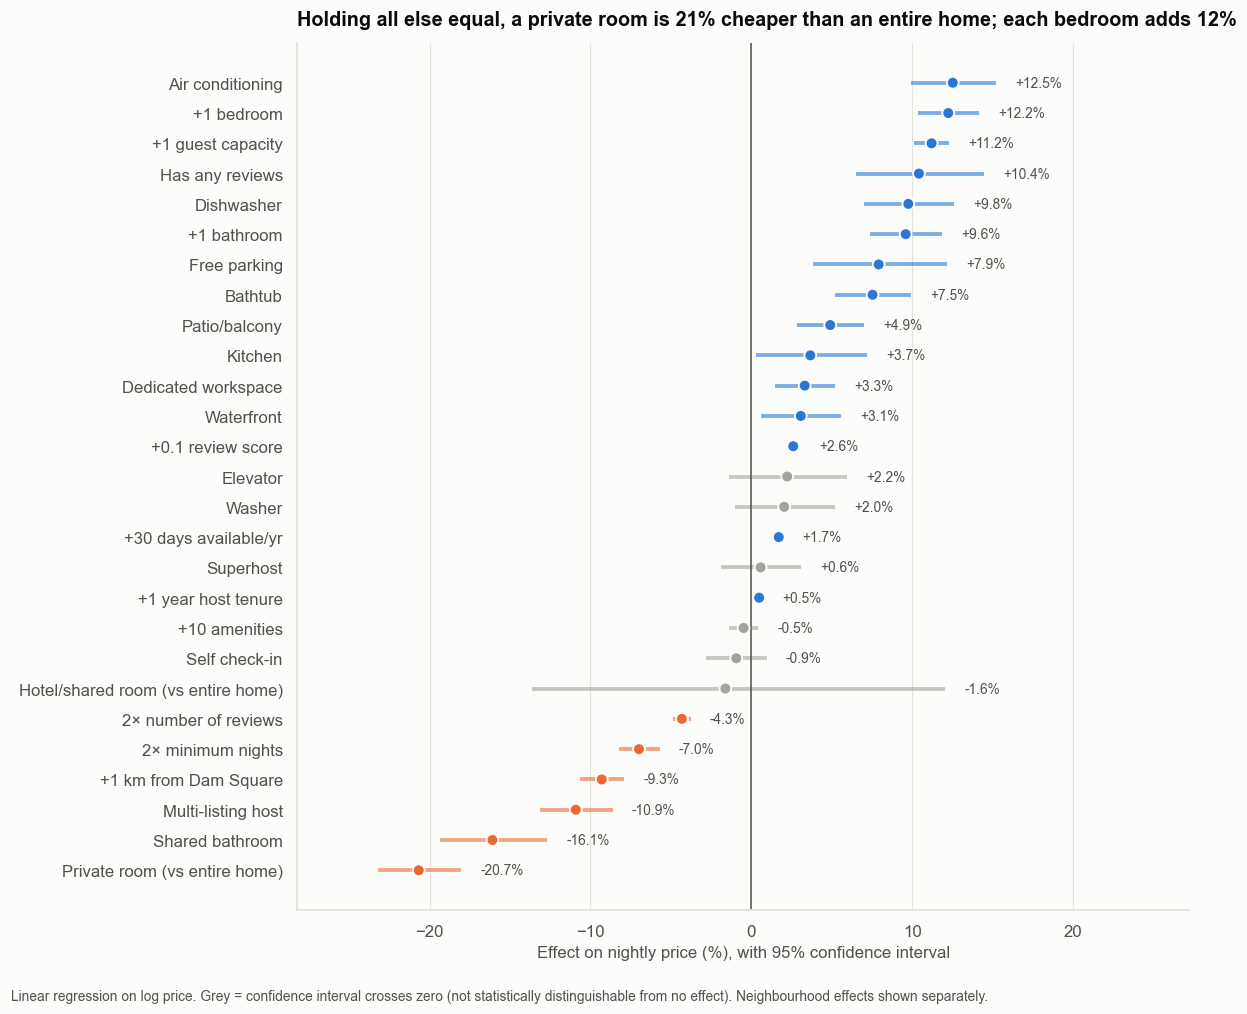

In [7]:
fig, ax = plt.subplots(figsize=(11, 9))
ypos = np.arange(len(eff))
colors = [(BLUE if v > 0 else ORANGE) if s else NEUTRAL for v, s in zip(eff["effect_%"], eff["significant"])]
ax.hlines(ypos, eff["ci_low_%"], eff["ci_high_%"], color=colors, lw=2.5, alpha=0.6)
ax.scatter(eff["effect_%"], ypos, color=colors, s=60, zorder=3, edgecolor=SURFACE, linewidth=1.2)
for i, (v, hi) in enumerate(zip(eff["effect_%"], eff["ci_high_%"])):
    ax.text(max(hi, v) + 1.2, i, f"{v:+.1f}%", va="center", fontsize=9, color=TEXT_SECONDARY)
ax.axvline(0, color=TEXT_SECONDARY, lw=1)
ax.set_yticks(ypos, eff.index)
ax.set_xlim(eff["ci_low_%"].min() - 5, eff["ci_high_%"].max() + 12)
pr = eff.loc["Private room (vs entire home)", "effect_%"]
bd = eff.loc["+1 bedroom", "effect_%"]
ax.set(title=f"Holding all else equal, a private room is {abs(pr):.0f}% cheaper than an entire home; each bedroom adds {bd:.0f}%",
       xlabel="Effect on nightly price (%), with 95% confidence interval", ylabel="")
ax.grid(axis="y", visible=False)
fig.text(0.01, -0.02, "Linear regression on log price. Grey = confidence interval crosses zero (not statistically distinguishable from no effect). "
         "Neighbourhood effects shown separately.", color=TEXT_SECONDARY, fontsize=9)
plt.tight_layout()
save_fig(fig, "05_linear_coefficients")
plt.show()

### Neighbourhood effects (vs De Baarsjes - Oud-West, same size/type/amenities)

In [8]:
nbh = coef[coef.index.str.startswith("nbh_")][["effect_%", "ci_low_%", "ci_high_%", "significant"]].copy()
nbh.index = nbh.index.str.replace("nbh_", "")
nbh = nbh.join(df["neighbourhood_cleansed"].value_counts().rename("listings"))
nbh.sort_values("effect_%", ascending=False).round(1)

,effect_%,ci_low_%,ci_high_%,significant,listings
Gaasperdam - Driemond,35.8,14.6,60.9,True,31
Bijlmer-Centrum,21.0,5.8,38.3,True,42
Bijlmer-Oost,10.1,-6.6,29.7,False,24
De Aker - Nieuw Sloten,8.8,-4.2,23.7,False,45
Zuid,7.7,3.4,12.3,True,400
IJburg - Zeeburgereiland,3.7,-5.7,14.1,False,114
De Pijp - Rivierenbuurt,3.0,-0.4,6.4,False,664
Buitenveldert - Zuidas,1.9,-6.6,11.1,False,81
Centrum-West,0.8,-3.0,4.9,False,795
Centrum-Oost,-4.0,-7.5,-0.3,True,623


**Read neighbourhood and distance together.** The model already charges −9% per km from Dam Square, so a far-out neighbourhood such as Gaasperdam (~10 km) gets a large distance penalty that its positive neighbourhood term partly cancels out. Their *combined* effect is still negative, and their confidence intervals are wide because they have few listings. After controlling for distance, the robust signal is that **Zuid** carries a premium (+8%) and **Noord** (Oud-Noord, Noord-West, Noord-Oost: −17% to −27%) a clear discount, consistent with Noord being across the IJ river and less accessible.

## 4. Random forest feature importance
Impurity-based importances are biased toward continuous features, so we use **permutation importance on the test set**: how much R² drops when a feature's values are shuffled. All neighbourhood dummies are shuffled together as one *Neighbourhood* feature, and likewise for *Room type*.

In [9]:
groups = {"Neighbourhood": [c for c in X.columns if c.startswith("nbh_")],
          "Room type": [c for c in X.columns if c.startswith("room_")]}
IMP_NAMES = {"accommodates": "Guest capacity", "bedrooms": "Bedrooms", "bathrooms": "Bathrooms",
             "amenity_count": "Amenity count", "dist_centre_km": "Distance to centre",
             "host_tenure_years": "Host tenure", "availability_365": "Days available",
             "review_scores_rating": "Review score", "log_reviews": "Number of reviews",
             "log_min_nights": "Minimum nights", "has_reviews": "Has reviews"}
for c in X.columns:
    if not c.startswith(("nbh_", "room_")):
        groups[IMP_NAMES.get(c, LABELS.get(c, c))] = [c]

rng = np.random.default_rng(SEED)
base_r2 = r2_score(y_test, rf.predict(X_test))
imp = {}
for name, cols in groups.items():
    drops = []
    for _ in range(5):
        Xp = X_test.copy()
        idx = rng.permutation(len(Xp))
        Xp[cols] = Xp[cols].values[idx]
        drops.append(base_r2 - r2_score(y_test, rf.predict(Xp)))
    imp[name] = (np.mean(drops), np.std(drops))
imp = pd.DataFrame(imp, index=["importance", "std"]).T.sort_values("importance", ascending=False)
imp.head(15).round(4)

,importance,std
Distance to centre,0.1739,0.0037
Bedrooms,0.1410,0.0106
Room type,0.1244,0.0047
Guest capacity,0.1000,0.0038
Number of reviews,0.0449,0.0056
Days available,0.0395,0.0060
Bathrooms,0.0253,0.0045
Review score,0.0192,0.0017
Neighbourhood,0.0173,0.0027
Shared bathroom,0.0133,0.0015


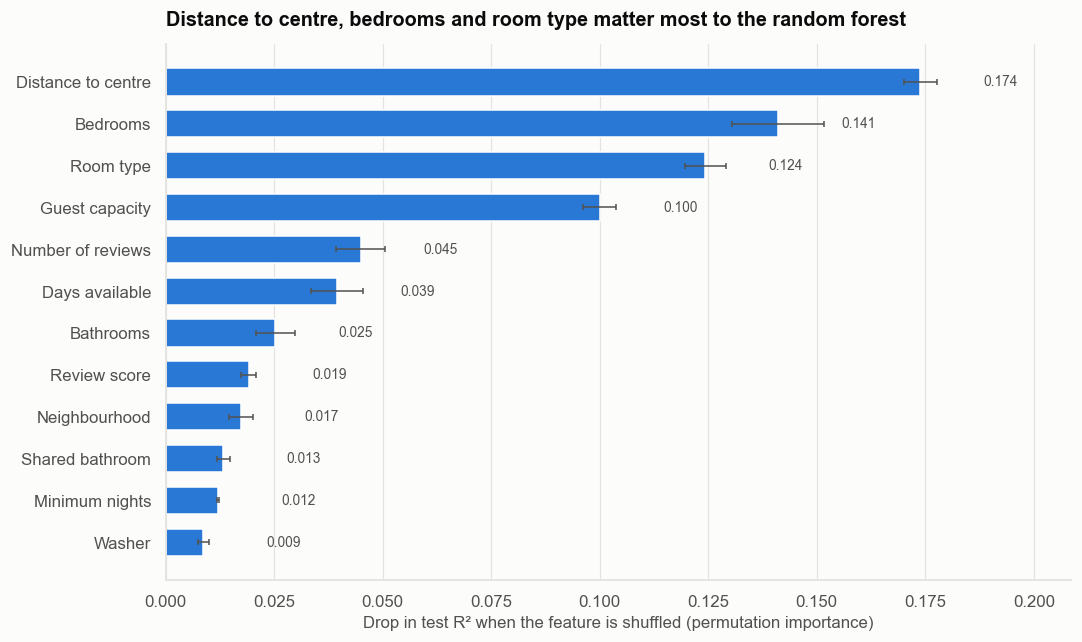

In [10]:
top_imp = imp.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_imp.index, top_imp["importance"], xerr=top_imp["std"], color=BLUE, height=0.65,
        error_kw={"ecolor": TEXT_SECONDARY, "lw": 1, "capsize": 2})
for i, v in enumerate(top_imp["importance"]):
    ax.text(v + top_imp["std"].max() + 0.004, i, f"{v:.3f}", va="center", fontsize=9, color=TEXT_SECONDARY)
ax.set_xlim(0, top_imp["importance"].max() * 1.2)
ax.set(title=f"{imp.index[0]}, {imp.index[1].lower()} and {imp.index[2].lower()} matter most to the random forest",
       xlabel="Drop in test R² when the feature is shuffled (permutation importance)", ylabel="")
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "05_feature_importance")
plt.show()

## 5. How to price your listing

A model prediction is only a starting point. Below, the random forest estimates a price for a few typical new-host profiles, alongside the **interquartile range of real comparable listings** (same room type, same neighbourhood, same guest capacity). New listings have no reviews, so profiles are set to `has_reviews = False`, superhost = False.

In [11]:
def profile(neighbourhood, room="Entire home/apt", guests=2, bedrooms=1, bathrooms=1.0, amenities=35,
            extra_flags=(), multi=False):
    row = pd.Series(0.0, index=X.columns)
    r = {"Hotel room": "Hotel/shared room", "Shared room": "Hotel/shared room"}.get(room, room)
    if f"room_{r}" in row: row[f"room_{r}"] = 1
    if f"nbh_{neighbourhood}" in row: row[f"nbh_{neighbourhood}"] = 1
    nb = df[df["neighbourhood_cleansed"] == neighbourhood]
    row["accommodates"], row["bedrooms"], row["bathrooms"] = guests, bedrooms, bathrooms
    row["amenity_count"] = amenities
    row["dist_centre_km"] = nb["dist_centre_km"].median()
    row["host_tenure_years"] = 0
    row["availability_365"] = df["availability_365"].median()
    row["review_scores_rating"] = df["review_scores_rating"].median()
    row["log_reviews"], row["has_reviews"] = 0, 0
    row["log_min_nights"] = np.log1p(df["minimum_nights"].median())
    row["is_multi_host"] = float(multi)
    for f in ("amen_kitchen", "amen_washer") if room == "Entire home/apt" else ():
        row[f] = 1
    for f in extra_flags:
        row[f] = 1
    return row

SCENARIOS = {
    "1-bed flat, 2 guests, De Pijp": dict(neighbourhood="De Pijp - Rivierenbuurt"),
    "1-bed flat, 2 guests, Bos en Lommer": dict(neighbourhood="Bos en Lommer"),
    "2-bed flat, 4 guests, Centrum-West": dict(neighbourhood="Centrum-West", guests=4, bedrooms=2),
    "2-bed flat, 4 guests, Noord-West": dict(neighbourhood="Noord-West", guests=4, bedrooms=2),
    "2-bed flat, 4 guests, Centrum-West + dishwasher, bathtub, balcony": dict(
        neighbourhood="Centrum-West", guests=4, bedrooms=2, amenities=50,
        extra_flags=("amen_dishwasher", "amen_bathtub", "amen_balcony")),
    "Private room, 2 guests, Oud-West": dict(neighbourhood="De Baarsjes - Oud-West", room="Private room", amenities=25),
}
rows = []
for name, kw in SCENARIOS.items():
    x = profile(**kw)
    comps = df[(df["room_type"] == kw.get("room", "Entire home/apt")) &
               (df["neighbourhood_cleansed"] == kw["neighbourhood"]) &
               (df["accommodates"] == kw.get("guests", 2))]["price"]
    rows.append({"scenario": name,
                 "RF estimate €": np.expm1(rf.predict(x.to_frame().T)[0]),
                 "Linear estimate €": np.expm1(lin.predict(x.to_frame().T)[0]),
                 "comps n": len(comps),
                 "comps 25th pct €": comps.quantile(0.25), "comps median €": comps.median(),
                 "comps 75th pct €": comps.quantile(0.75)})
pricing = pd.DataFrame(rows).set_index("scenario").round(0)
pricing

,RF estimate €,Linear estimate €,comps n,comps 25th pct €,comps median €,comps 75th pct €
scenario,,,,,,
"1-bed flat, 2 guests, De Pijp",283.0,279.0,284,251.0,300.0,362.0
"1-bed flat, 2 guests, Bos en Lommer",244.0,222.0,116,203.0,246.0,291.0
"2-bed flat, 4 guests, Centrum-West",452.0,446.0,151,387.0,520.0,713.0
"2-bed flat, 4 guests, Noord-West",271.0,226.0,108,254.0,305.0,364.0
"2-bed flat, 4 guests, Centrum-West + dishwasher, bathtub, balcony",611.0,549.0,151,387.0,520.0,713.0
"Private room, 2 guests, Oud-West",180.0,206.0,81,130.0,161.0,200.0


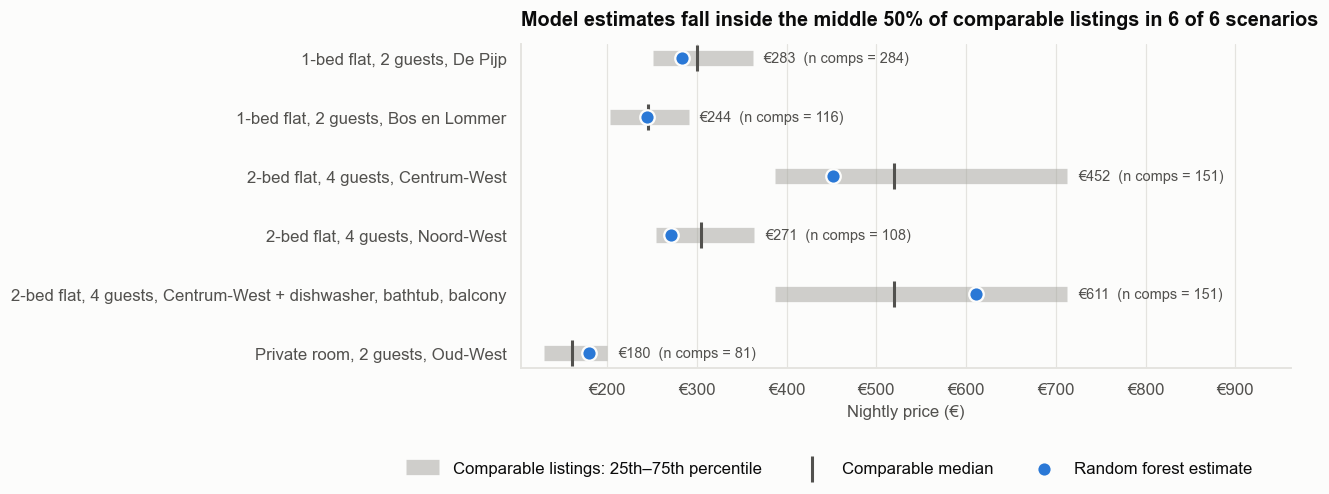

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
plot = pricing.iloc[::-1]
ypos = np.arange(len(plot))
ax.hlines(ypos, plot["comps 25th pct €"], plot["comps 75th pct €"], color=NEUTRAL, lw=10, alpha=0.5,
          label="Comparable listings: 25th–75th percentile")
ax.scatter(plot["comps median €"], ypos, marker="|", s=300, color=TEXT_SECONDARY, lw=2, label="Comparable median", zorder=3)
ax.scatter(plot["RF estimate €"], ypos, color=BLUE, s=90, zorder=4, edgecolor=SURFACE, linewidth=1.5,
           label="Random forest estimate")
for i, (v, n) in enumerate(zip(plot["RF estimate €"], plot["comps n"])):
    ax.text(plot["comps 75th pct €"].iloc[i] + 12, i, f"€{v:,.0f}  (n comps = {n:.0f})", va="center", fontsize=9.5, color=TEXT_SECONDARY)
ax.set_yticks(ypos, plot.index)
ax.xaxis.set_major_formatter(euro)
ax.set_xlim(plot["comps 25th pct €"].min() * 0.8, plot["comps 75th pct €"].max() * 1.35)
ax.legend(loc="lower center", bbox_to_anchor=(0.4, -0.38), ncol=3)
inside = ((plot["RF estimate €"] >= plot["comps 25th pct €"]) & (plot["RF estimate €"] <= plot["comps 75th pct €"])).sum()
ax.set(title=f"Model estimates fall inside the middle 50% of comparable listings in {inside} of {len(plot)} scenarios",
       xlabel="Nightly price (€)", ylabel="")
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "05_pricing_guide")
plt.show()

### How to price your listing: a 5-step playbook

1. **Find your comparables first.** Filter to the same room type, neighbourhood and guest capacity. Their median is your anchor (e.g. a 2-guest 1-bed in De Pijp: €300 median, middle 50% €251–€362, n = 284).
2. **Adjust for size and layout.** Holding everything else constant, each extra bedroom adds ~12% and each extra guest slot ~11%; a shared bathroom costs ~16%.
3. **Adjust for location within the city.** Each km from Dam Square is worth about −9%. Noord neighbourhoods price 17–27% below otherwise-equal homes in Oud-West; Zuid commands about +8%.
4. **Invest in the amenities that pay.** Air conditioning (+12.5%), a dishwasher (+9.8%), a bathtub (+7.5%), free parking (+7.9%) and a balcony (+4.9%) carry significant controlled premiums. Simply listing *more* amenities does not (+10 amenities: −0.5%, not significant).
5. **Launch slightly below the anchor, then raise.** Listings with no reviews price ~10% lower than reviewed equivalents; each +0.1 in review score is worth ~2.6%. Superhost status itself adds nothing measurable (+0.6%, not significant), so build reviews first and raise prices as the score settles above 4.8.

**For an investor:** size and location explain most of the price, so **bedrooms in the inner ring** (Zuid, De Pijp, Centrum, Oud-West) are what earn the higher nightly rate. Amenity upgrades are the cheapest lever: in the Centrum-West example above, adding a dishwasher, bathtub, balcony and fuller amenity list moves the model estimate from €452 to €611.

## Key Takeaways

- **Predictive power is moderate and honest:** on 1,218 held-out listings the random forest reaches **R² = 0.67** (MAE €77, median error 18%) and linear regression **R² = 0.64** (MAE €80, median error 19%), against a naive baseline MAE of €130. 5-fold CV agrees (0.67 ± 0.01 and 0.64 ± 0.02). About a third of price variation is due to things the data doesn't capture (interior quality, photos, views, dynamic pricing).
- **The forest only modestly beats the linear model** (+0.03 R²) and overfits somewhat (train R² 0.88), so the simple linear model is a good, explainable choice for pricing guidance.
- **Biggest controlled effects (linear model):** private room **−21%** vs entire home, shared bathroom −16%, each bedroom **+12%**, each extra guest +11%, each km from Dam Square **−9%**, multi-listing host −11%, air conditioning **+12.5%**, dishwasher +10%, bathtub +7.5%.
- **What does *not* move price once everything else is controlled:** superhost status (+0.6%, n.s.), total amenity count (−0.5% per 10, n.s.), self check-in, elevator and washer (all n.s.). The raw washer premium of +44% from notebook 03 was almost entirely a size effect.
- **Most important features (random forest permutation importance):** distance to centre (0.174 R² drop), bedrooms (0.141), room type (0.124), guest capacity (0.100); every amenity on its own is below 0.01.
- **Pricing guide:** for all 6 test scenarios the model's estimate lies inside the interquartile range of real comparable listings, e.g. €283 for a 1-bed in De Pijp (comps €251–€362) and €180 for a private room in Oud-West (comps €130–€200).